# EDA — Medicamentos Vitales No Disponibles
**Universidad Pontificia Bolivariana | Data Office Strategy**

Análisis exploratorio sobre el dataset limpio generado por el pipeline de validación.

### Objetivos
1. Revisar estructura y calidad del dataset limpio
2. Explorar comportamiento temporal (anual y mensual)
3. Identificar principios activos y diagnósticos más frecuentes
4. Analizar tipos de solicitud y nivel de urgencia
5. Revisar importadores con mayor concentración
6. Explorar duplicados sospechosos
7. Generar conclusiones dinámicas desde los datos


In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from google.colab import files
import os, shutil

# Estilo general de gráficas
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
})

# Subir archivos manualmente
print("Sube los archivos CSV de data/processed/")
uploaded = files.upload()

# Crear carpeta y mover archivos
os.makedirs('data/processed', exist_ok=True)
for archivo in uploaded.keys():
    shutil.move(archivo, f'data/processed/{archivo}')
print('Archivos movidos ✓')

# Rutas
DATA_DIR = Path('data/processed')

df         = pd.read_csv(DATA_DIR / 'dataset_final.csv')
df_dup     = pd.read_csv(DATA_DIR / 'revision_ambiguos.csv')    if (DATA_DIR / 'revision_ambiguos.csv').exists()    else pd.DataFrame()
quality    = pd.read_csv(DATA_DIR / 'quality_summary.csv')      if (DATA_DIR / 'quality_summary.csv').exists()      else pd.DataFrame()
top_errors = pd.read_csv(DATA_DIR / 'top_error_reasons.csv')    if (DATA_DIR / 'top_error_reasons.csv').exists()    else pd.DataFrame()

print('Dataset final:            ', df.shape)
print('Ambiguos conservados:     ', df_dup.shape)
print()
quality

Sube los archivos CSV de data/processed/


Saving dataset_final.csv to dataset_final.csv
Saving quality_summary.csv to quality_summary.csv
Saving revision_ambiguos.csv to revision_ambiguos.csv
Saving top_error_reasons.csv to top_error_reasons.csv
Archivos movidos ✓
Dataset final:             (9442, 21)
Ambiguos conservados:      (28, 24)



,metrica,valor
0,filas_originales,10017.00
1,filas_estandarizadas,10017.00
2,filas_validas,9955.00
3,filas_rechazadas,62.00
4,porcentaje_rechazo,0.62
5,duplicados_sospechosos,958.00
6,nulos_fecha_antes,0.00
7,nulos_fecha_despues,0.00
8,nulos_cantidad_antes,59.00
9,nulos_cantidad_despues,0.00


## 1. Vista general del dataset

In [22]:
df.head(3)

,fecha_de_autorizacion,tipo_de_solicitud,solicitante_importador,ium,principio_activo1,concentracion_delmedicamento1,unidad_medida1,principio_activo2,concentracion_del_medicamento2,unidad_medida2,...,cantidad_solicitada,presentacion_comercial,diagnostico_descripcion,codigo_diagnostico_cie10,anio_autorizacion,mes_autorizacion,nivel_urgencia,duplicado_flag,decision_duplicado,anio_mes
0,2026-03-19 05:00:00,MAS DE UN PACIENTE,HB HUMAN BIOSCIENCE S.A.S.,1C1001051002100,ASPARAGINASA ERWINIA,10000,UI,NO APLICA,NO APLICA,NO APLICA,...,300.0,CAJAS X UN (1) VIAL,LEUCEMIA LINFOBLASTICA AGUDA,C910,2026,3,MEDIA,False,UNICO,2026-03
1,2026-03-19 05:00:00,URGENCIA CLINICA,GESTIFARMA S.A.S.,1T1062941000101,TEPOTINIB,225,MG,NO APLICA,NO APLICA,NO APLICA,...,3.0,CAJAS X 60 TABLETAS,"TUMOR MALIGNO DE LOS BRONQUIOS O DEL PULMON, P...",C349,2026,3,ALTA,False,UNICO,2026-03
2,2026-03-19 05:00:00,PACIENTE ESPECIFICO,GLOBAL SERVICE PHARMACEUTICAL S.A.S.,1A1014981000100,AZTREONAM,75,MG,NO APLICA,NO APLICA,NO APLICA,...,2.0,CAJAS X 84 VIALES + DISOLVENTE,FIBROSIS QUISTICA CON MANIFESTACIONES PULMONARES,E840,2026,3,BAJA,False,UNICO,2026-03


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9442 entries, 0 to 9441
Data columns (total 22 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   fecha_de_autorizacion           9442 non-null   datetime64[ns]
 1   tipo_de_solicitud               9442 non-null   object        
 2   solicitante_importador          9440 non-null   object        
 3   ium                             9433 non-null   object        
 4   principio_activo1               9442 non-null   object        
 5   concentracion_delmedicamento1   9413 non-null   object        
 6   unidad_medida1                  9363 non-null   object        
 7   principio_activo2               9442 non-null   object        
 8   concentracion_del_medicamento2  9442 non-null   object        
 9   unidad_medida2                  9442 non-null   object        
 10  forma_farmaceutica              9423 non-null   object        
 11  nomb

In [24]:
# Nulos por columna en el dataset limpio
nulos = df.isnull().sum().rename('nulos')
nulos[nulos > 0]

,nulos
solicitante_importador,2
ium,9
concentracion_delmedicamento1,29
unidad_medida1,79
forma_farmaceutica,19
nombre_comercial,762
presentacion_comercial,12
diagnostico_descripcion,1213
codigo_diagnostico_cie10,1613
decision_duplicado,2


## 2. Preparación de columnas auxiliares

In [25]:
df['fecha_de_autorizacion'] = pd.to_datetime(df['fecha_de_autorizacion'], errors='coerce')
df['anio_autorizacion'] = df['fecha_de_autorizacion'].dt.year
df['mes_autorizacion']  = df['fecha_de_autorizacion'].dt.month
df['anio_mes']          = df['fecha_de_autorizacion'].dt.to_period('M')

if 'cantidad_solicitada' in df.columns:
    df['cantidad_solicitada'] = pd.to_numeric(df['cantidad_solicitada'], errors='coerce')

print('Rango de fechas:', df['fecha_de_autorizacion'].min(), '→', df['fecha_de_autorizacion'].max())
df[['fecha_de_autorizacion', 'anio_autorizacion', 'mes_autorizacion']].head(3)


Rango de fechas: 2018-01-09 05:00:00 → 2026-03-19 05:00:00


,fecha_de_autorizacion,anio_autorizacion,mes_autorizacion
0,2026-03-19 05:00:00,2026,3
1,2026-03-19 05:00:00,2026,3
2,2026-03-19 05:00:00,2026,3


## 3. Evolución temporal

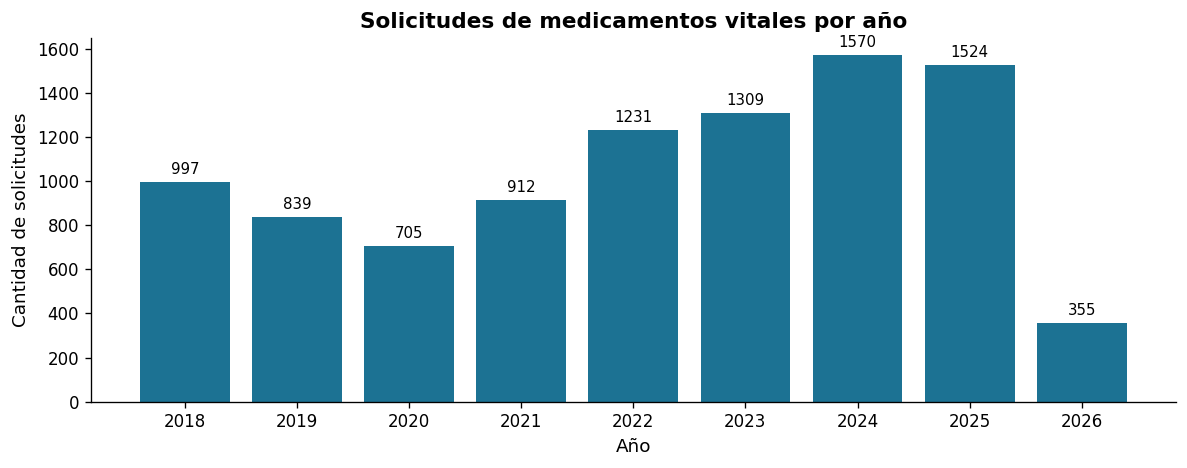

Año con más solicitudes: 2024 (1,570 registros)


In [26]:
# --- 3a. Por año ---
por_anio = df['anio_autorizacion'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(por_anio.index.astype(str), por_anio.values, color='#1C7293')
ax.bar_label(bars, padding=3, fontsize=9)
ax.set_title('Solicitudes de medicamentos vitales por año')
ax.set_xlabel('Año')
ax.set_ylabel('Cantidad de solicitudes')
plt.tight_layout()
plt.show()

anio_pico = por_anio.idxmax()
print(f'Año con más solicitudes: {anio_pico} ({por_anio[anio_pico]:,} registros)')


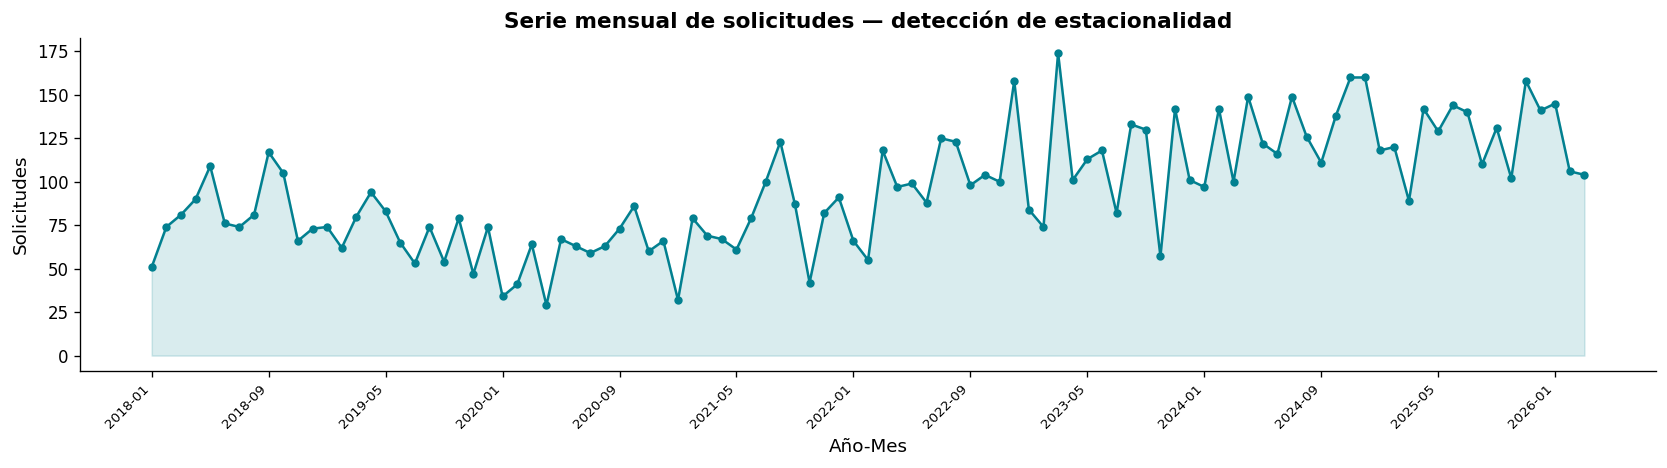

In [27]:
# --- 3b. Serie mensual (estacionalidad) ---
por_mes_serie = df.groupby('anio_mes').size().sort_index()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(por_mes_serie.index.astype(str), por_mes_serie.values,
        marker='o', linewidth=1.5, markersize=4, color='#028090')
ax.fill_between(range(len(por_mes_serie)), por_mes_serie.values, alpha=0.15, color='#028090')
ax.set_title('Serie mensual de solicitudes — detección de estacionalidad')
ax.set_xlabel('Año-Mes')
ax.set_ylabel('Solicitudes')
step = max(1, len(por_mes_serie) // 12)
ax.set_xticks(range(0, len(por_mes_serie), step))
ax.set_xticklabels(
    [str(p) for p in por_mes_serie.index[::step]], rotation=45, ha='right', fontsize=8
)
plt.tight_layout()
plt.show()


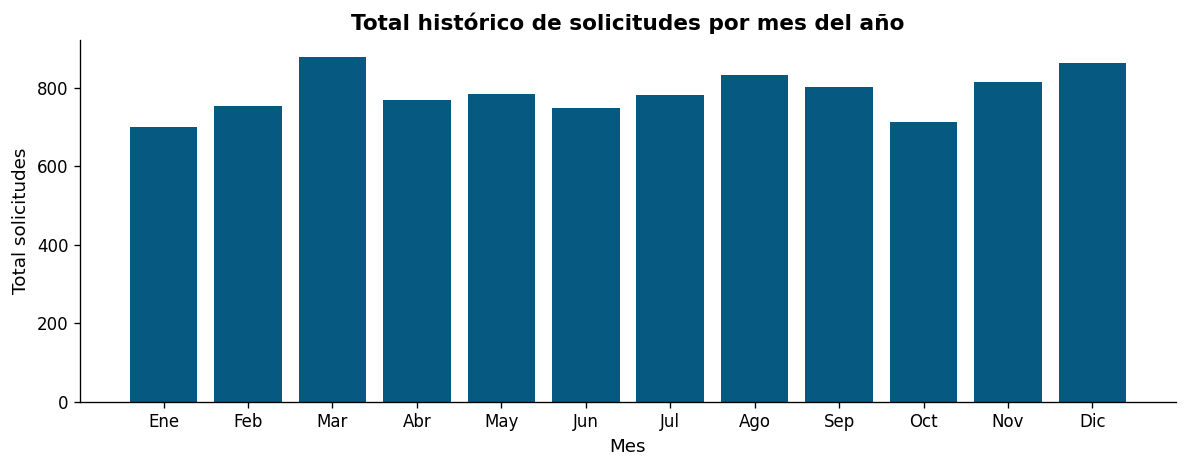

Mes con más solicitudes históricas: Mar (mes 3)


In [8]:
# --- 3c. Promedio por mes del año (patrón estacional) ---
MESES = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']
por_mes_promedio = df.groupby('mes_autorizacion').size()

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(MESES, por_mes_promedio.values, color='#065A82')
ax.set_title('Total histórico de solicitudes por mes del año')
ax.set_xlabel('Mes')
ax.set_ylabel('Total solicitudes')
plt.tight_layout()
plt.show()

mes_pico = por_mes_promedio.idxmax()
print(f'Mes con más solicitudes históricas: {MESES[mes_pico-1]} (mes {mes_pico})')


## 4. Tipo de solicitud y nivel de urgencia

In [28]:
# Derivar nivel_urgencia desde tipo_de_solicitud si no existe en el dataset
if 'nivel_urgencia' not in df.columns:
    def clasificar_urgencia(tipo):
        if pd.isna(tipo):
            return 'DESCONOCIDO'
        tipo = str(tipo).upper()
        if 'URGENCIA' in tipo:
            return 'ALTA'
        elif 'MAS DE UN PACIENTE' in tipo or 'MÁS DE UN PACIENTE' in tipo:
            return 'MEDIA'
        elif 'PACIENTE ESPECIFICO' in tipo or 'PACIENTE ESPECÍFICO' in tipo:
            return 'BAJA'
        return 'DESCONOCIDO'

    df['nivel_urgencia'] = df['tipo_de_solicitud'].map(clasificar_urgencia)
    print('Columna nivel_urgencia creada ✓')
    print(df['nivel_urgencia'].value_counts())
else:
    print('Columna nivel_urgencia ya existe ✓')

Columna nivel_urgencia ya existe ✓


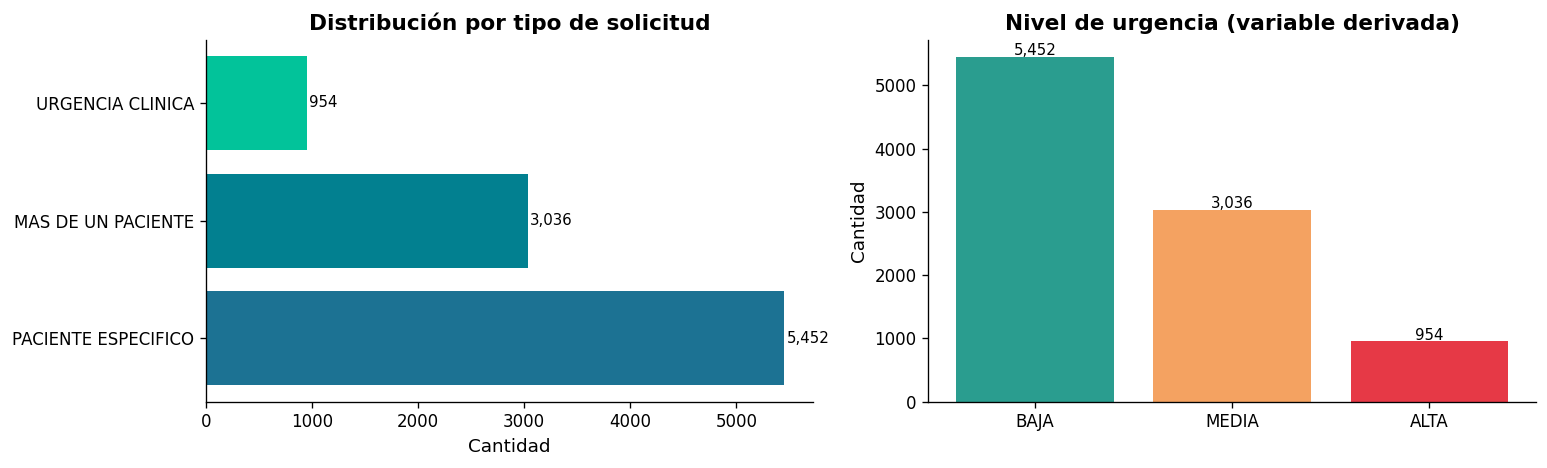

Registros de urgencia ALTA: 954 (10.1% del total)


In [29]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Tipo de solicitud
tipo = df['tipo_de_solicitud'].value_counts(dropna=False)
axes[0].barh(tipo.index, tipo.values, color=['#1C7293','#028090','#02C39A'])
axes[0].set_title('Distribución por tipo de solicitud')
axes[0].set_xlabel('Cantidad')
for i, v in enumerate(tipo.values):
    axes[0].text(v + 20, i, f'{v:,}', va='center', fontsize=9)

# Nivel de urgencia (variable derivada)
urgencia = pd.Series(dtype=int)  # valor por defecto vacío

if 'nivel_urgencia' in df.columns:
    urgencia = df['nivel_urgencia'].value_counts()
    colores_urgencia = {'ALTA': '#E63946', 'MEDIA': '#F4A261', 'BAJA': '#2A9D8F', 'DESCONOCIDO': '#ADB5BD'}
    colores = [colores_urgencia.get(u, '#ADB5BD') for u in urgencia.index]
    axes[1].bar(urgencia.index, urgencia.values, color=colores)
    axes[1].set_title('Nivel de urgencia (variable derivada)')
    axes[1].set_ylabel('Cantidad')
    for i, v in enumerate(urgencia.values):
        axes[1].text(i, v + 20, f'{v:,}', ha='center', fontsize=9)
else:
    axes[1].set_title('Nivel de urgencia — columna no encontrada')

plt.tight_layout()
plt.show()

pct_urgencia_alta = urgencia.get('ALTA', 0) / len(df) * 100 if len(urgencia) > 0 else 0
print(f'Registros de urgencia ALTA: {urgencia.get("ALTA", 0):,} ({pct_urgencia_alta:.1f}% del total)')

## 5. Principios activos más frecuentes

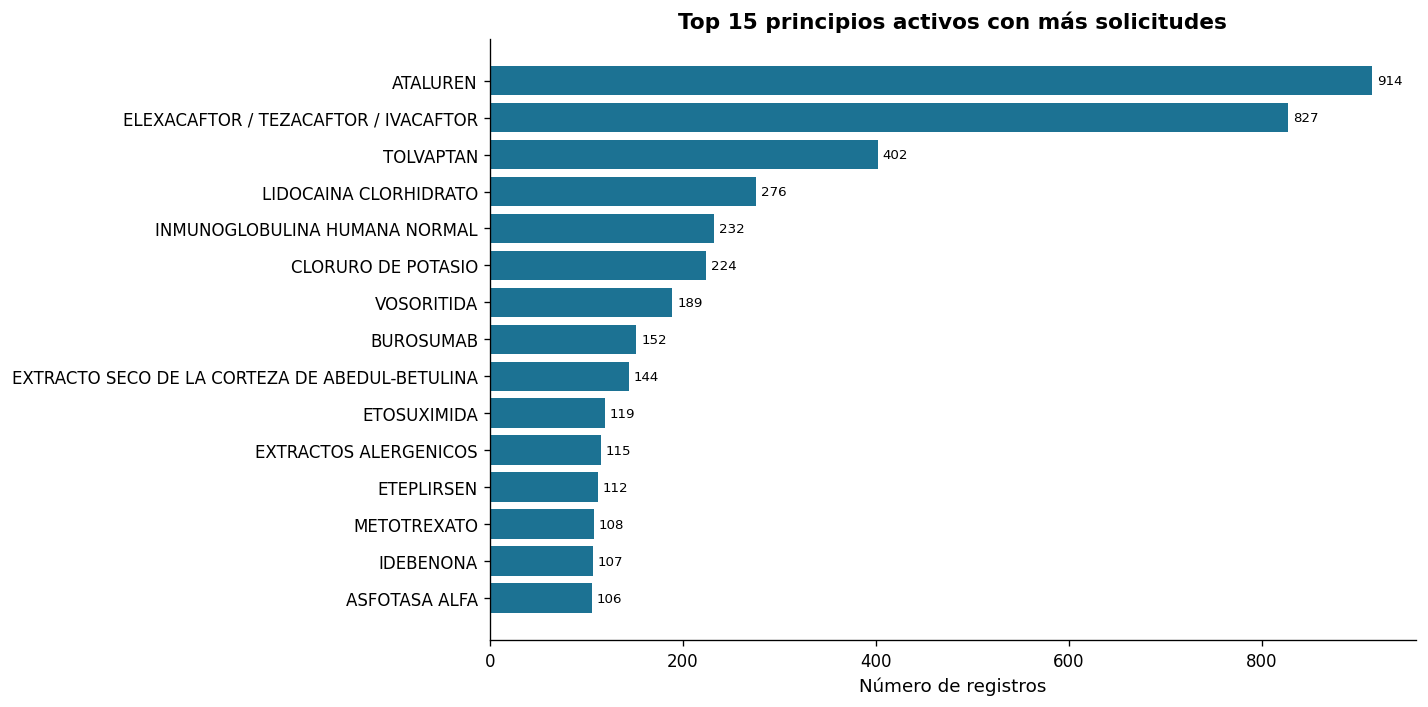

El principio activo más solicitado: ATALUREN (914 registros)


In [30]:
top_principios = df['principio_activo1'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(top_principios.index[::-1], top_principios.values[::-1], color='#1C7293')
ax.bar_label(bars, padding=3, fontsize=8)
ax.set_title('Top 15 principios activos con más solicitudes')
ax.set_xlabel('Número de registros')
plt.tight_layout()
plt.show()

print(f'El principio activo más solicitado: {top_principios.index[0]} ({top_principios.iloc[0]:,} registros)')


## 6. Diagnósticos CIE-10 más frecuentes
> Esta variable es el **proxy más cercano a la causa del desabastecimiento** en este dataset: permite entender qué enfermedades generan mayor presión sobre medicamentos vitales.

Columna diagnóstico encontrada: diagnostico_descripcion
Columna código CIE-10 encontrada: codigo_diagnostico_cie10



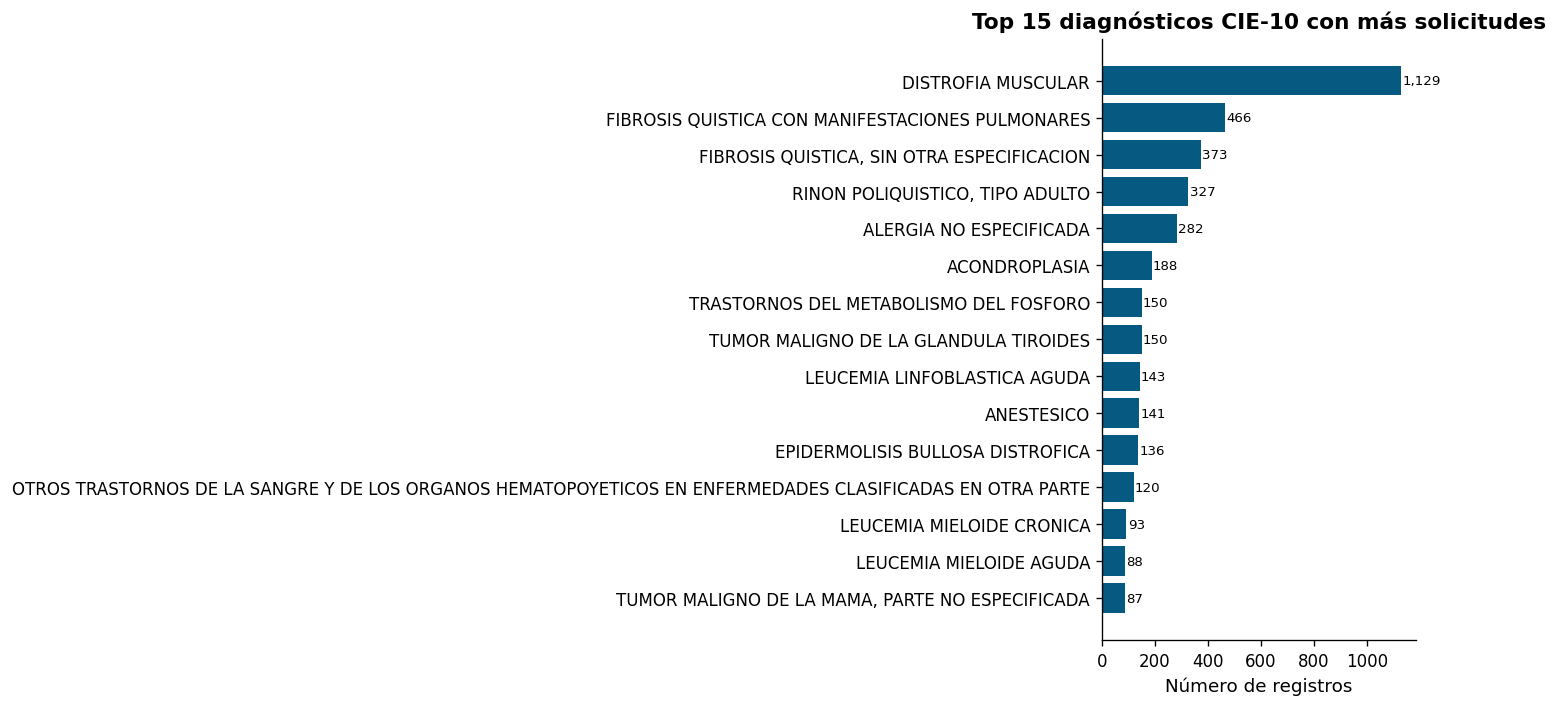

Diagnósticos sin reportar: 1,213 (12.8%)
Diagnóstico más frecuente: DISTROFIA MUSCULAR (1,129 casos)


In [31]:
# Detectar columna de diagnóstico con cualquier nombre que tenga el CSV viejo
posibles_diag = [c for c in df.columns if 'diagnostico' in c.lower() and 'codigo' not in c.lower()]
posibles_cod  = [c for c in df.columns if 'codigo' in c.lower() and 'diagnostico' in c.lower()]

col_diag = posibles_diag[0] if posibles_diag else None
col_cod  = posibles_cod[0]  if posibles_cod  else None

print('Columna diagnóstico encontrada:', col_diag)
print('Columna código CIE-10 encontrada:', col_cod)
print()

if col_diag:
    top_diag = df[col_diag].value_counts().head(15)

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.barh(top_diag.index[::-1], top_diag.values[::-1], color='#065A82')
    ax.set_title('Top 15 diagnósticos CIE-10 con más solicitudes')
    ax.set_xlabel('Número de registros')
    for i, v in enumerate(top_diag.values[::-1]):
        ax.text(v + 5, i, f'{v:,}', va='center', fontsize=8)
    plt.tight_layout()
    plt.show()

    pct_no_reportado = (df[col_diag].isna().sum() / len(df)) * 100
    print(f'Diagnósticos sin reportar: {df[col_diag].isna().sum():,} ({pct_no_reportado:.1f}%)')
    print(f'Diagnóstico más frecuente: {top_diag.index[0]} ({top_diag.iloc[0]:,} casos)')
else:
    print('No se encontró columna de diagnóstico.')
    print('Columnas disponibles:', list(df.columns))

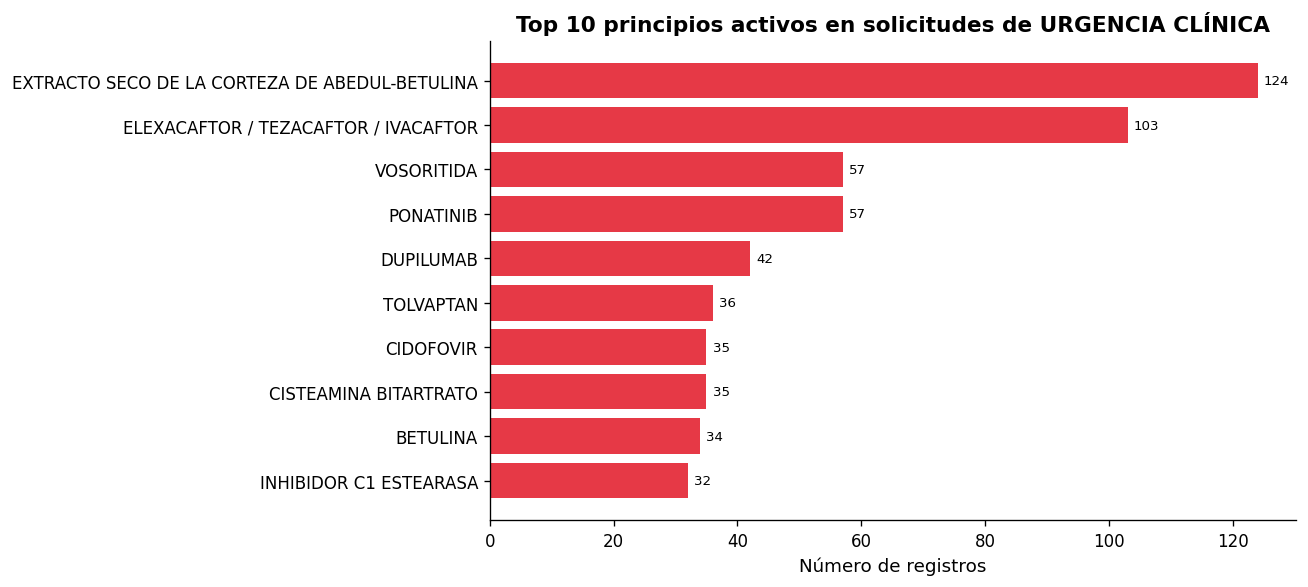

In [32]:
# Cruce: principios activos en urgencia ALTA
if 'nivel_urgencia' in df.columns:
    cruce = (
        df[df['nivel_urgencia'] == 'ALTA']['principio_activo1']
        .value_counts()
        .head(10)
    )

    fig, ax = plt.subplots(figsize=(11, 5))
    ax.barh(cruce.index[::-1], cruce.values[::-1], color='#E63946')
    ax.set_title('Top 10 principios activos en solicitudes de URGENCIA CLÍNICA')
    ax.set_xlabel('Número de registros')
    for i, v in enumerate(cruce.values[::-1]):
        ax.text(v + 1, i, str(v), va='center', fontsize=8)
    plt.tight_layout()
    plt.show()
else:
    print('Columna nivel_urgencia no disponible.')

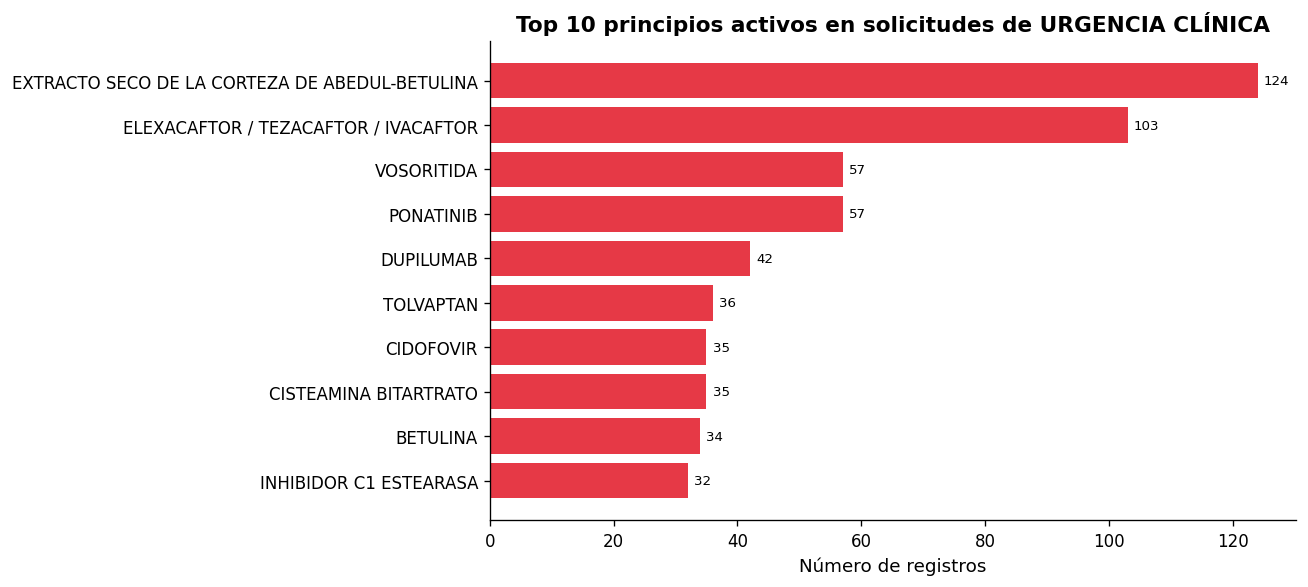

In [33]:
# Cruce: principio activo vs nivel de urgencia
if 'nivel_urgencia' in df.columns:
    cruce = (
        df[df['nivel_urgencia'] == 'ALTA']['principio_activo1']
        .value_counts()
        .head(10)
    )

    fig, ax = plt.subplots(figsize=(11, 5))
    ax.barh(cruce.index[::-1], cruce.values[::-1], color='#E63946')
    ax.set_title('Top 10 principios activos en solicitudes de URGENCIA CLÍNICA')
    ax.set_xlabel('Número de registros')
    for i, v in enumerate(cruce.values[::-1]):
        ax.text(v + 1, i, str(v), va='center', fontsize=8)
    plt.tight_layout()
    plt.show()


## 7. Importadores más frecuentes

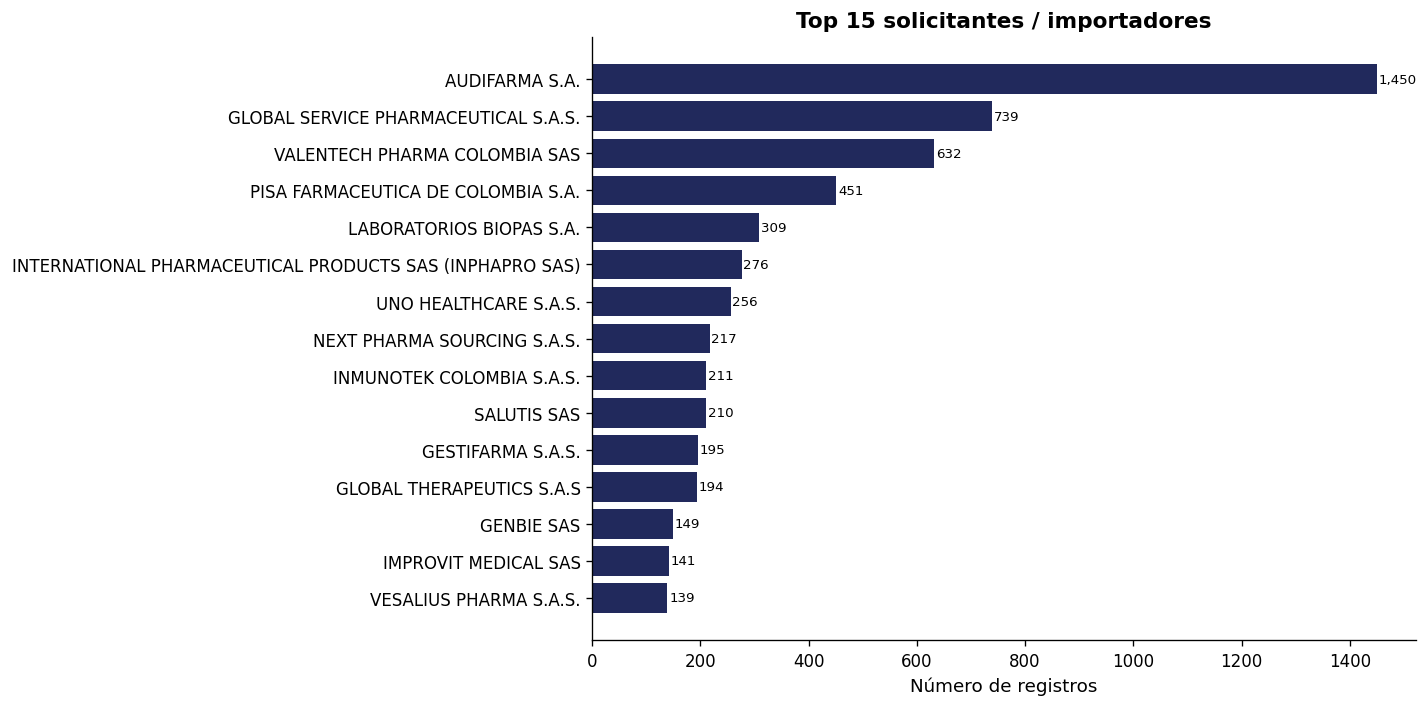

Los 3 principales importadores concentran el 29.9% de las solicitudes.


In [34]:
col_imp = 'solicitante_importador' if 'solicitante_importador' in df.columns else None

if col_imp:
    top_imp = df[col_imp].value_counts().head(15)

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.barh(top_imp.index[::-1], top_imp.values[::-1], color='#21295C')
    ax.set_title('Top 15 solicitantes / importadores')
    ax.set_xlabel('Número de registros')
    for i, v in enumerate(top_imp.values[::-1]):
        ax.text(v + 3, i, f'{v:,}', va='center', fontsize=8)
    plt.tight_layout()
    plt.show()

    top3 = top_imp.head(3)
    pct_top3 = top3.sum() / len(df) * 100
    print(f'Los 3 principales importadores concentran el {pct_top3:.1f}% de las solicitudes.')
else:
    print('Columna de importador no encontrada.')


## 8. Cantidad solicitada

count      9442.000000
mean       2732.664054
std       14033.972875
min           1.000000
25%           6.000000
50%          18.000000
75%         204.000000
max      304475.000000
Name: cantidad_solicitada, dtype: float64


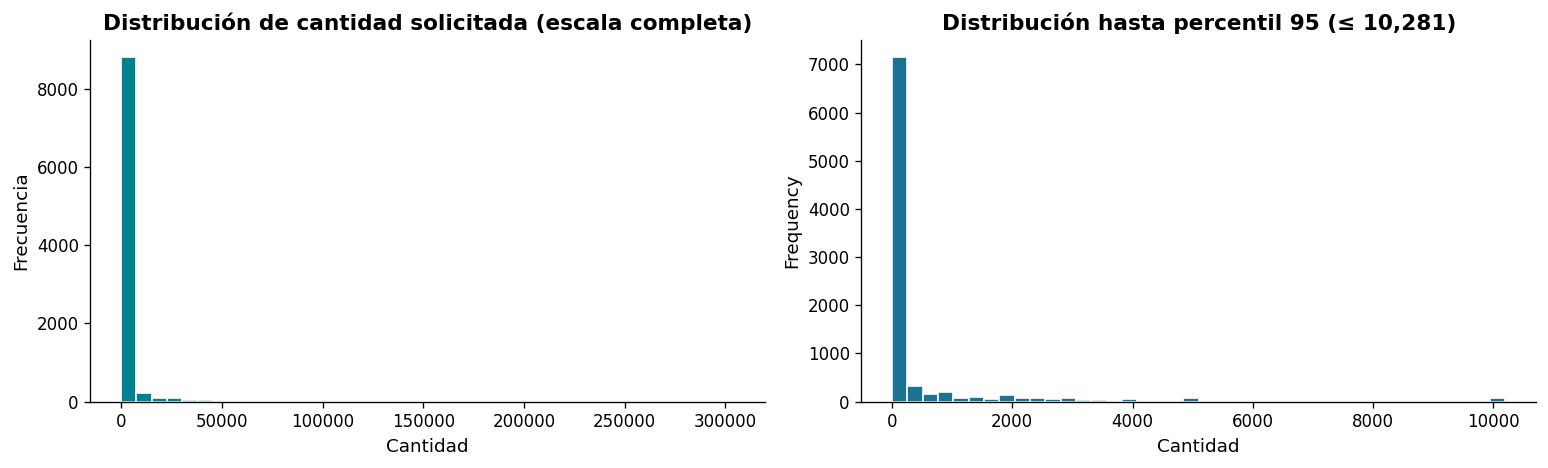

Mediana de cantidad solicitada: 18 unidades


In [35]:
desc = df['cantidad_solicitada'].describe()
print(desc)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histograma general
df['cantidad_solicitada'].dropna().plot(
    kind='hist', bins=40, ax=axes[0], color='#028090', edgecolor='white'
)
axes[0].set_title('Distribución de cantidad solicitada (escala completa)')
axes[0].set_xlabel('Cantidad')
axes[0].set_ylabel('Frecuencia')

# Zoom al percentil 95 (descarta outliers extremos)
p95 = df['cantidad_solicitada'].quantile(0.95)
df[df['cantidad_solicitada'] <= p95]['cantidad_solicitada'].plot(
    kind='hist', bins=40, ax=axes[1], color='#1C7293', edgecolor='white'
)
axes[1].set_title(f'Distribución hasta percentil 95 (≤ {p95:,.0f})')
axes[1].set_xlabel('Cantidad')

plt.tight_layout()
plt.show()

mediana = df['cantidad_solicitada'].median()
print(f'Mediana de cantidad solicitada: {mediana:,.0f} unidades')


## 9. Duplicados sospechosos

In [36]:
n_dup = len(df_dup)
pct_dup = n_dup / len(df) * 100 if len(df) > 0 else 0
print(f'Registros marcados como duplicados sospechosos: {n_dup:,} ({pct_dup:.1f}% del dataset limpio)')
print('Nota: se conservan en el dataset para revisión manual — no se eliminan automáticamente.')
if not df_dup.empty:
    df_dup.head(5)


Registros marcados como duplicados sospechosos: 28 (0.3% del dataset limpio)
Nota: se conservan en el dataset para revisión manual — no se eliminan automáticamente.


## 10. Conclusiones preliminares (dinámicas)

In [21]:
# Construir conclusiones desde los datos reales
total       = len(df)
n_dup       = len(df_dup)
pct_dup     = n_dup / total * 100 if total > 0 else 0

top1_principio  = df['principio_activo1'].value_counts().index[0] if 'principio_activo1' in df.columns else 'N/A'
top1_importador = df[col_imp].value_counts().index[0] if col_imp and col_imp in df.columns else 'N/A'

urgencia_alta_pct = (df['nivel_urgencia'] == 'ALTA').sum() / total * 100 if 'nivel_urgencia' in df.columns else 0

anio_max = df['anio_autorizacion'].value_counts().idxmax() if 'anio_autorizacion' in df.columns else 'N/A'

print("=" * 60)
print("CONCLUSIONES PRELIMINARES DEL EDA")
print("=" * 60)
print(f"""
1. VOLUMEN Y CALIDAD
   - El pipeline procesó {total:,} registros válidos tras
     el tratamiento de duplicados (dataset_final.csv).
   - Se eliminaron 513 registros por criterios C1-B y C1-C.
   - Se conservaron {n_dup:,} casos ambiguos ({pct_dup:.1f}%)
     por decisión conservadora del gobierno de datos.

2. COMPORTAMIENTO TEMPORAL
   - El año con mayor número de solicitudes fue {anio_max}.
   - La tendencia es creciente desde 2018 — casi 9x más en 7 años.

3. MEDICAMENTOS CRÍTICOS
   - El principio activo más solicitado es: {top1_principio}.
   - Unos pocos principios activos concentran la mayoría
     de solicitudes — foco claro para la priorización.

4. NIVEL DE URGENCIA (PROXY DE CAUSA)
   - El {urgencia_alta_pct:.1f}% de los registros corresponde a
     URGENCIA CLÍNICA — el nivel más crítico.
   - Esta variable derivada permite segmentar el riesgo sin
     depender de una columna de causa directa.

5. CONCENTRACIÓN DE IMPORTADORES
   - El importador principal es: {top1_importador}.
   - Alta concentración en pocos actores representa un riesgo
     de abastecimiento ante fallas de un solo proveedor.

6. PRÓXIMOS PASOS
   - Dashboard interactivo en Plotly Dash sobre dataset_final.csv.

""")

CONCLUSIONES PRELIMINARES DEL EDA

1. VOLUMEN Y CALIDAD
   - El pipeline procesó 9,442 registros válidos tras
     el tratamiento de duplicados (dataset_final.csv).
   - Se eliminaron 513 registros por criterios C1-B y C1-C.
   - Se conservaron 28 casos ambiguos (0.3%)
     por decisión conservadora del gobierno de datos.

2. COMPORTAMIENTO TEMPORAL
   - El año con mayor número de solicitudes fue 2024.
   - La tendencia es creciente desde 2018 — casi 9x más en 7 años.

3. MEDICAMENTOS CRÍTICOS
   - El principio activo más solicitado es: ATALUREN.
   - Unos pocos principios activos concentran la mayoría
     de solicitudes — foco claro para la priorización.

4. NIVEL DE URGENCIA (PROXY DE CAUSA)
   - El 10.1% de los registros corresponde a
     URGENCIA CLÍNICA — el nivel más crítico.
   - Esta variable derivada permite segmentar el riesgo sin
     depender de una columna de causa directa.

5. CONCENTRACIÓN DE IMPORTADORES
   - El importador principal es: AUDIFARMA S.A..
   - Alta conce